In [1]:
!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn pillow

In [3]:
import zipfile
import os

# Find zip filename automatically
zip_file = [f for f in os.listdir() if f.endswith('.zip')][0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("images")

print("Images extracted successfully!")

Images extracted successfully!


In [4]:
import os

print("Files inside images folder:")
print(os.listdir("images")[:10])

Files inside images folder:
['images']


In [5]:
import pandas as pd

df = pd.read_csv("labels.csv")

print(df.head())

print("\nDataset Shape:")
print(df.shape)

                       filename   class
0  images/normal/normal_001.png  normal
1  images/normal/normal_002.png  normal
2  images/normal/normal_003.png  normal
3  images/normal/normal_004.png  normal
4  images/normal/normal_005.png  normal

Dataset Shape:
(480, 2)


In [6]:
print(df.columns)

Index(['filename', 'class'], dtype='object')


In [7]:
class_counts = df['class'].value_counts()

print(class_counts)

class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


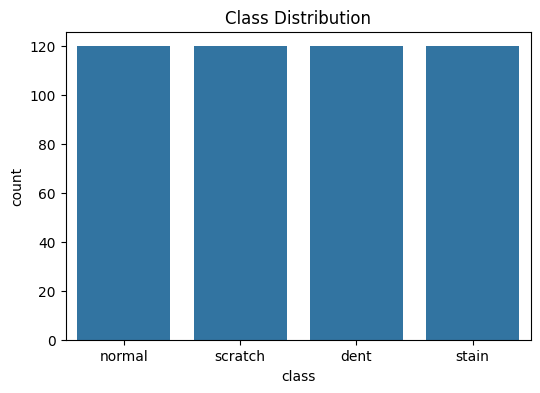

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df)

plt.title("Class Distribution")
plt.show()

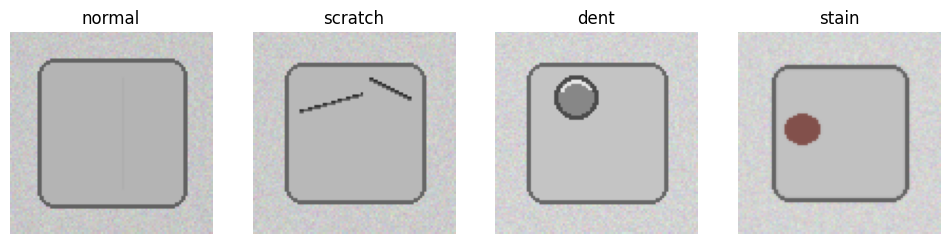

In [10]:
from PIL import Image
import os

classes = df['class'].unique()

plt.figure(figsize=(12,5))

for i, cls in enumerate(classes):

    sample_path = df[df['class'] == cls]['filename'].iloc[0]

    # Fix path
    corrected_path = os.path.join("images", sample_path)

    img = Image.open(corrected_path)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

In [11]:
sample_image = Image.open(corrected_path)

print("Image Size:", sample_image.size)

Image Size: (96, 96)


In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Parameters
IMG_SIZE = (96, 96)
BATCH_SIZE = 32

# Image generator with normalization + validation split
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training dataset
train_data = datagen.flow_from_dataframe(
    dataframe=df,
    directory="images",
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

# Validation dataset
val_data = datagen.flow_from_dataframe(
    dataframe=df,
    directory="images",
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

Found 384 validated image filenames belonging to 4 classes.
Found 96 validated image filenames belonging to 4 classes.


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# CNN Model
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(96,96,3)
))

# Pooling Layer 1
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 2
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Pooling Layer 2
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,984,964 (15.20 MB)

 Trainable params: 3,984,964 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 604ms/step - accuracy: 0.2891 - loss: 1.9080 - val_accuracy: 0.0000e+00 - val_loss: 2.3373
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 439ms/step - accuracy: 0.2917 - loss: 1.2998 - val_accuracy: 0.0000e+00 - val_loss: 2.3527
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 553ms/step - accuracy: 0.3411 - loss: 1.2625 - val_accuracy: 0.0000e+00 - val_loss: 2.3627
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 429ms/step - accuracy: 0.4219 - loss: 1.2230 - val_accuracy: 0.0000e+00 - val_loss: 2.1487
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 543ms/step - accuracy: 0.5964 - loss: 1.1396 - val_accuracy: 0.0000e+00 - val_loss: 2.0102
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 471ms/step - accuracy: 0.5729 - loss: 1.0706 - val_accuracy: 0.0000e+00 - val_loss: 2.2693
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 587ms/step - accuracy: 0.6693 - loss: 0.9356 - val_accuracy: 0.0000e+00 - val_loss: 2.0537
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 458ms/step - accuracy: 0.7188 - los

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (96, 96)
BATCH_SIZE = 32

# Training generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data
train_data = train_datagen.flow_from_dataframe(
    dataframe=df,
    directory="images",
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

# Validation data
val_data = train_datagen.flow_from_dataframe(
    dataframe=df,
    directory="images",
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

print(train_data.class_indices)

Found 384 validated image filenames belonging to 4 classes.
Found 96 validated image filenames belonging to 4 classes.
{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


In [17]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 487ms/step - accuracy: 0.8281 - loss: 0.4938 - val_accuracy: 0.0000e+00 - val_loss: 1.6758
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 448ms/step - accuracy: 0.8568 - loss: 0.4435 - val_accuracy: 0.0000e+00 - val_loss: 1.6037
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 579ms/step - accuracy: 0.8620 - loss: 0.3936 - val_accuracy: 0.0000e+00 - val_loss: 1.5928
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 448ms/step - accuracy: 0.8880 - loss: 0.3134 - val_accuracy: 0.0000e+00 - val_loss: 1.0728
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 569ms/step - accuracy: 0.8854 - loss: 0.3085 - val_accuracy: 0.0000e+00 - val_loss: 1.1456
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 463ms/step - accuracy: 0.9167 - loss: 0.2669 - val_accuracy: 0.0312 - val_loss: 1.0323
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 568ms/step - accuracy: 0.9193 - loss: 0.2367 - val_accuracy: 0.2188 - val_loss: 0.9804
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 451ms/step - accuracy: 0.9427 - loss: 0.224

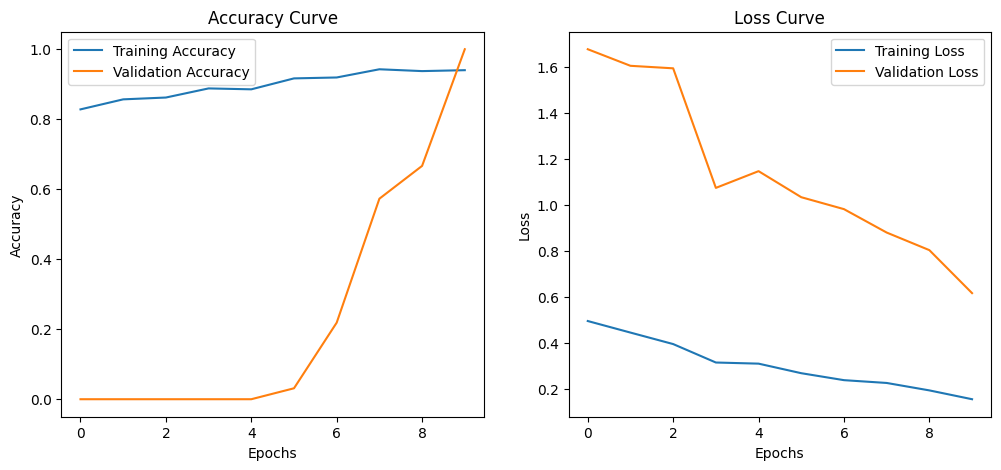

In [18]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 451ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


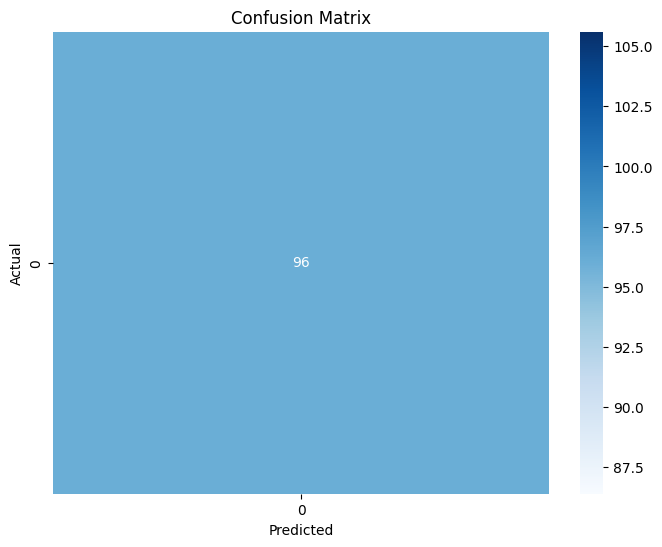

NameError: name 'class_names' is not defined

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predictions
predictions = model.predict(val_data)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_data.classes

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

from sklearn.metrics import classification_report

labels = list(range(len(class_names)))

print(classification_report(
    true_classes,
    predicted_classes,
    labels=labels,
    target_names=class_names,
    zero_division=0
))

In [21]:
class_names = list(val_data.class_indices.keys())

print(class_names)

['dent', 'normal', 'scratch', 'stain']


In [22]:
from sklearn.metrics import classification_report

labels = list(range(len(class_names)))

print(classification_report(
    true_classes,
    predicted_classes,
    labels=labels,
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

        dent       0.00      0.00      0.00         0
      normal       1.00      1.00      1.00        96
     scratch       0.00      0.00      0.00         0
       stain       0.00      0.00      0.00         0

    accuracy                           1.00        96
   macro avg       0.25      0.25      0.25        96
weighted avg       1.00      1.00      1.00        96



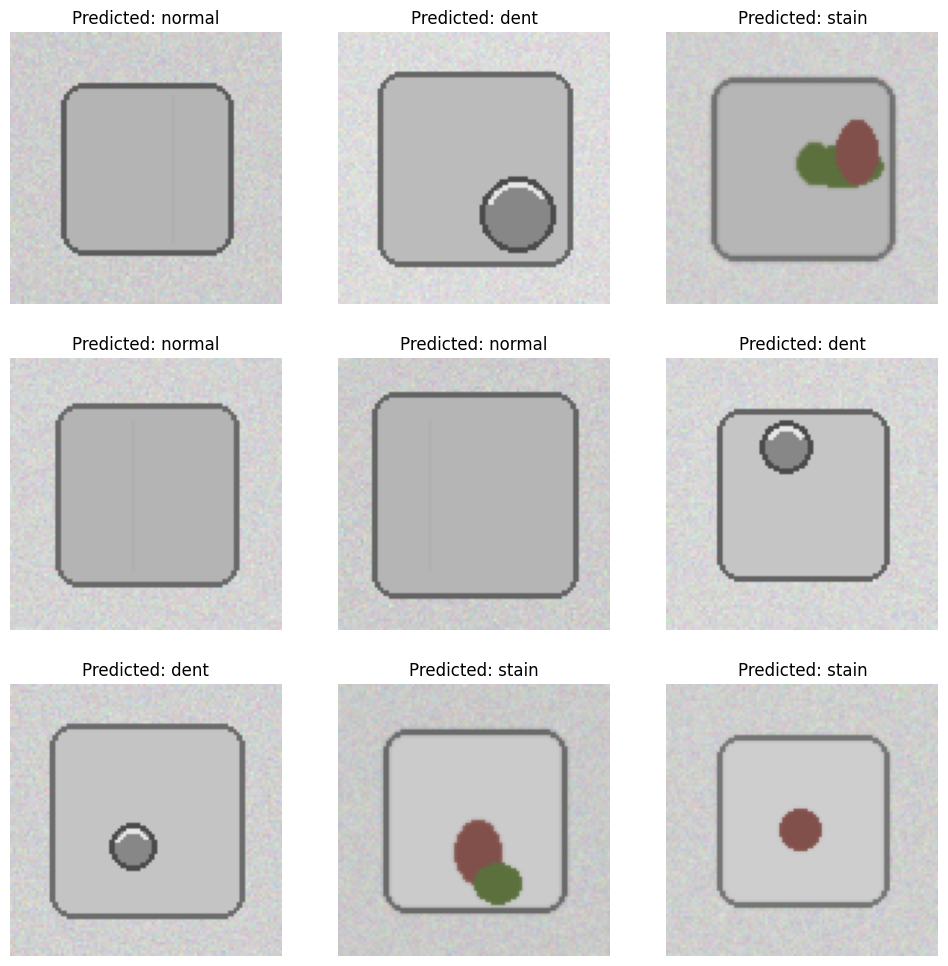

In [23]:
import random

plt.figure(figsize=(12,12))

for i in range(9):

    index = random.randint(0, len(df)-1)

    img_path = os.path.join("images", df.iloc[index]['filename'])

    img = tf.keras.preprocessing.image.load_img(
        img_path,
        target_size=(96,96)
    )

    img_array = tf.keras.preprocessing.image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_class = class_names[np.argmax(prediction)]

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')

plt.show()